# Time series analysis

<div class="custom-button-row">
    <a 
        class="custom-button custom-download-button" href="../../notebooks/09_bobiac_exercises/group_work_2_oscillations_solution.ipynb" download>
        <i class="fas fa-download"></i> Download this Notebook
    </a>
    <a
    class="custom-button custom-download-button" href="https://colab.research.google.com/github/bobiac/bobiac-book/blob/gh-pages/colab_notebooks/09_bobiac_exercises/group_work_2_oscillations_solution.ipynb" target="_blank">
        <img class="button-icon" src="../../_static/logo/icon-google-colab.svg" alt="Open in Colab">
        Open in Colab
    </a>
</div>

In [27]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "pandas",
#     "seaborn",
#     "bobiac_tools @ git+https://github.com/bobiac/bobiac-tools.git"
# ]
# ///

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import skimage
import tifffile
from bobiac_tools import overlay_labels

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/max/Documents/bobiac/measurements2026/venv_test/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3579, in run_code
  File "/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_47620/2478314601.py", line 3, in <module>
    import matplotlib.pyplot as plt
ModuleNotFoundError: No module named 'matplotlib'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/max/Documents/bobiac/measurements2026/venv_test/lib/python3.10/site-packages/pygments/styles/__init__.py", line 45, in get_style_by_name
ModuleNotFoundError: No module named 'pygments.styles.default'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/max/Documents/bobiac/measurements2026/venv_test/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 2170, in showtraceback
  File "/Users/max/Documents/bobiac/meas

## Overview

In this notebook, we analyse time resolved data.

We have data of cells where the location of our gene of interes oscillates between the nucleus and the cytoplasm. Our question is **What is the frequency of the oscillations?**

We have a total of 16 time points with a temporal spacing of 30 min (🤔).
The background of the images was measured to be 4700.

You can find the data [here](https://github.com/bobiac/bobiac-book/releases/download/data-bobiac-2026/bobiac_exercises_oscillations.zip).

Time stack shape: (16, 3, 1040, 1392)

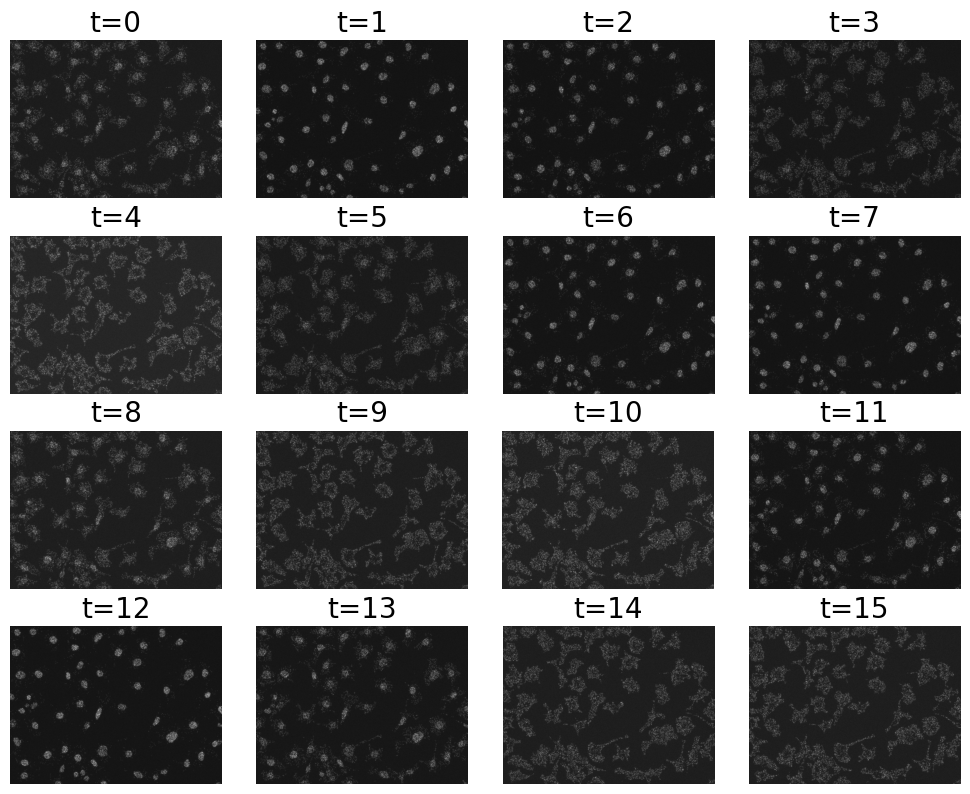

In [29]:
image_path = Path("../../_static/images/quant/03_time_series/images/F01_1615_tcyx.tif")

time_stack = tifffile.imread(image_path)
print(f"Time stack shape: {time_stack.shape}")  # (16, 3, 1040, 1392)


t_max = time_stack.shape[0]
ch = 2  # channel index for the oscillating gene of interest
fig = plt.figure(figsize=(10, 8))
for t in range(t_max):
    image = time_stack[t, ch, :, :]
    plt.subplot(4, 4, t + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"t={t}", fontsize=20)
    plt.axis("off")
plt.tight_layout()
plt.show()


These are the first eight time points.

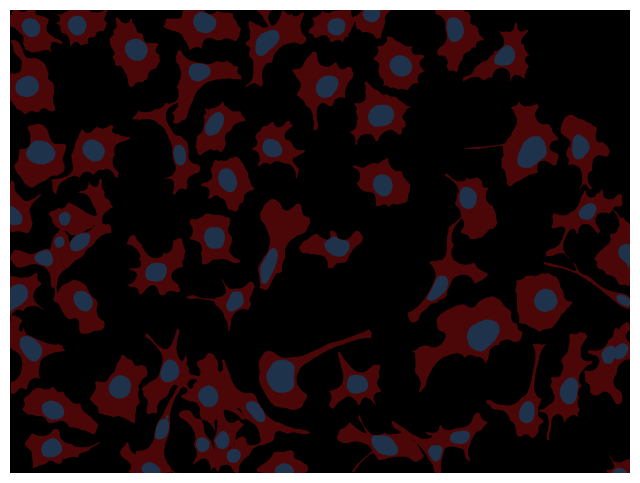

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [30]:
mask_cells = tifffile.imread(
    "../../_static/images/quant/03_time_series/masks/F01_1615_tcyx_cell_labels.tif"
)
mask_nuclei = tifffile.imread(
    "../../_static/images/quant/03_time_series/masks/F01_1615_tcyx_nuclei_labels.tif"
)

overlay_labels(label_mask=[mask_cells, mask_nuclei])

This are the two label masks for the nuclei and the cells.

### ✍️ Exercise: Perform this analysis

1. For the first time point (image) use `regionprops_table` to measure the expression level of each nucleus. Follow the steps of the previous notebooks.
2. Perform proper quality control and check that the measurements do not contain artefacts.
3. Set up batch processing to analyse all 16 images. Remember to keep track of where the data came from. Add a column `time` that contains the time at which the image was taken (e.g. 0, 0.5, 1, 1.5) (the unit is hours).
4. Use `sns.lineplot` to visualise the oscillations of individual cell as well as the average oscillations, and estimate the frequency.
5. BONUS: Instead of nuclear intensity, calculate the ratio of nuclear/cytoplasmic intensity.

## Solution

### 1. Measure nuclear intensity
First, we measure the intesities of all the nuclei in the image.

Load the first time point.

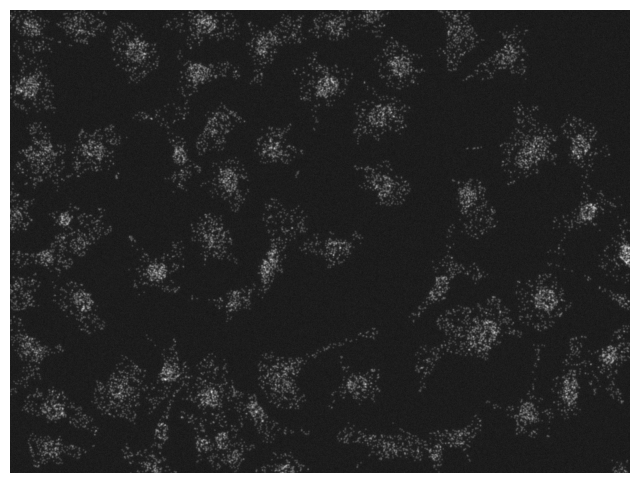

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [31]:
ch = 2  # channel index for the oscillating gene of interest
image_t0 = time_stack[0, ch, :, :]
overlay_labels(image=image_t0)

Remove boundary objects.

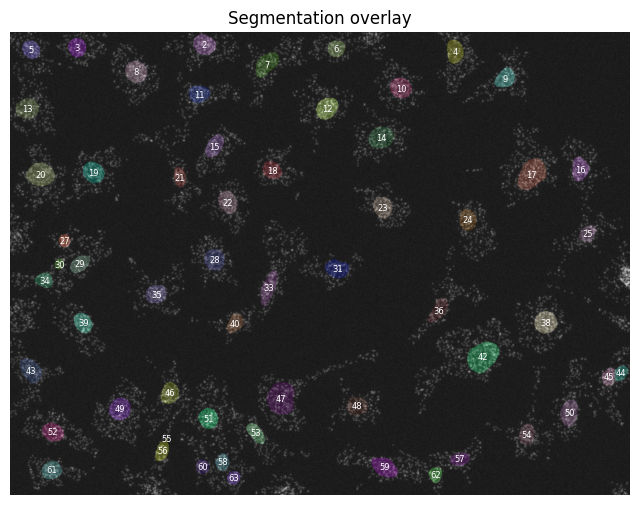

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [32]:
mask_nuclei = skimage.segmentation.clear_border(mask_nuclei)
overlay_labels(image=image_t0, label_mask=mask_nuclei)

Measure intesities with `regionprops_table` ans save measurements as `DataFrame`.

In [33]:
properties = ["area", "intensity_mean", "label"]
props = skimage.measure.regionprops_table(
    mask_nuclei, intensity_image=image_t0, properties=properties
)

df_nuc = pd.DataFrame(props)
print(df_nuc)

area  intensity_mean  label
0   1869.0     1219.043339      2
1   1430.0      948.851748      3
2   1681.0      891.096371      4
3   1356.0     1117.834071      5
4   1232.0     1028.202110      6
5   2114.0     1058.964049      7
6   1954.0     1140.899693      8
7   1576.0     1024.806472      9
8   1862.0     1176.601504     10
9   1555.0     1250.140836     11
10  1945.0     1325.883290     12
11  1948.0     1274.267967     13
12  2307.0     1073.438231     14
13  1599.0      931.551595     15
14  1646.0     1237.678007     16
15  3380.0     1080.149112     17
16  1440.0     1092.085417     18
17  1880.0     1091.045213     19
18  2691.0      976.980676     20
19  1030.0     1240.002913     21
20  1716.0     1213.378205     22
21  1696.0     1083.852005     23
22  1540.0     1165.322727     24
23  1086.0     1456.955801     25
24   618.0     1489.451456     27
25  1847.0      998.479697     28
26  1329.0      888.212190     29
27   438.0      806.287671     30
28  1825.0      950.421370     31
29  1913.0     1320.894929     33
30  1123.0     1105.219056     34
31  1664.0     1350.731971     35
32  1547.0     1082.393019     36
33  2081.0     1273.842864     38
34  1499.0     1207.787859     39
35  1279.0     1003.185301     40
36  3761.0     1127.747939     42
37  2040.0     1029.764216     43
38   829.0      864.540410     44
39   968.0     1430.487603     45
40  1639.0     1242.480171     46
41  3799.0      937.245591     47
42  1645.0     1066.477204     48
43  2022.0     1017.343225     49
44  1892.0     1197.726216     50
45  1673.0     1253.115959     51
46  1644.0     1135.153893     52
47  1275.0     1196.524706     53
48  1362.0     1168.959618     54
49    44.0     1205.840909     55
50  1095.0      942.811872     56
51  1056.0      944.766098     57
52   961.0     1143.874089     58
53  2026.0      850.837611     59
54   785.0     1107.979618     60
55  1543.0      998.966948     61
56   878.0     1070.775626     62
57   776.0      998.304124     63

Subtract background intensity from measurements. Background was measured to 460.

In [34]:
background_intensity = 460
df_nuc["intensity_bg_cor"] = df_nuc["intensity_mean"] - background_intensity
print(df_nuc["intensity_bg_cor"].head())
print(
    "\nAre there any negative values after background subtraction?",
    (df_nuc["intensity_bg_cor"] < 0).any(),
)

0    759.043339
1    488.851748
2    431.096371
3    657.834071
4    568.202110
Name: intensity_bg_cor, dtype: float64

Are there any negative values after background subtraction? False

Add `time` column.

In [35]:
t = 0  # index of the first time point in the stack
time = t * 0.5
print(time)

0.0

In [36]:
df_nuc["time"] = time

### 2. Quality control

<Axes: xlabel='intensity_bg_cor', ylabel='Count'>

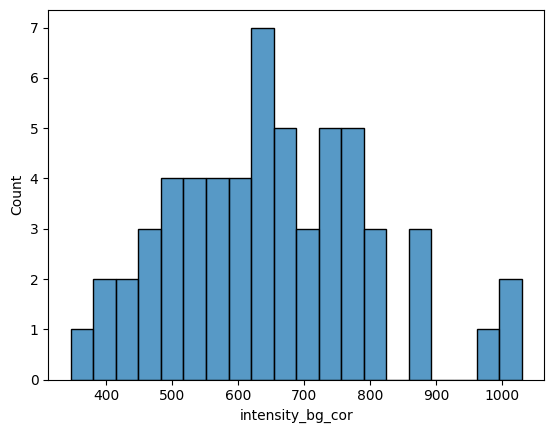

In [37]:
sns.histplot(
    data=df_nuc,
    x="intensity_bg_cor",
    bins=20,
)

Seems unsuspicious.

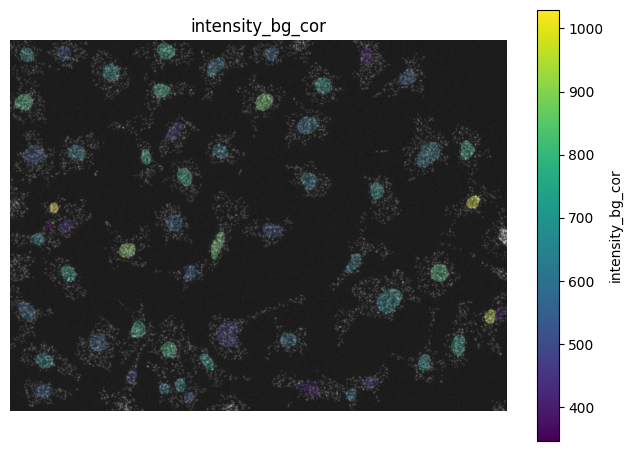

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'intensity_bg_cor'}>)

In [38]:
overlay_labels(
    image=image_t0,
    label_mask=mask_nuclei,
    df=df_nuc,
    id_col="label",
    measurement_col="intensity_bg_cor",
)

Looks fine.

### Batch processing

In [39]:
list_df = []

for t in range(t_max):
    image = time_stack[t, ch, :, :]
    props = skimage.measure.regionprops_table(
        mask_nuclei, intensity_image=image, properties=properties
    )
    sdf = pd.DataFrame(props)
    sdf["intensity_bg_cor"] = sdf["intensity_mean"] - background_intensity
    sdf["time"] = t * 0.5
    list_df.append(sdf)

df = pd.concat(list_df)
print(df)

area  intensity_mean  label  intensity_bg_cor  time
0   1869.0     1219.043339      2        759.043339   0.0
1   1430.0      948.851748      3        488.851748   0.0
2   1681.0      891.096371      4        431.096371   0.0
3   1356.0     1117.834071      5        657.834071   0.0
4   1232.0     1028.202110      6        568.202110   0.0
..     ...             ...    ...               ...   ...
53  2026.0      592.803060     59        132.803060   7.5
54   785.0      681.891720     60        221.891720   7.5
55  1543.0      659.832793     61        199.832793   7.5
56   878.0      750.211845     62        290.211845   7.5
57   776.0      684.514175     63        224.514175   7.5

[928 rows x 5 columns]

### Plotting

In [40]:
df.groupby(["label", "time"])["intensity_bg_cor"].mean().reset_index()

,label,time,intensity_bg_cor
0,2,0.0,759.043339
1,2,0.5,876.869984
2,2,1.0,658.683788
3,2,1.5,260.720171
4,2,2.0,283.440342
...,...,...,...
923,63,5.5,562.300258
924,63,6.0,695.213918
925,63,6.5,501.601804
926,63,7.0,250.744845


<Axes: xlabel='time', ylabel='intensity_bg_cor'>

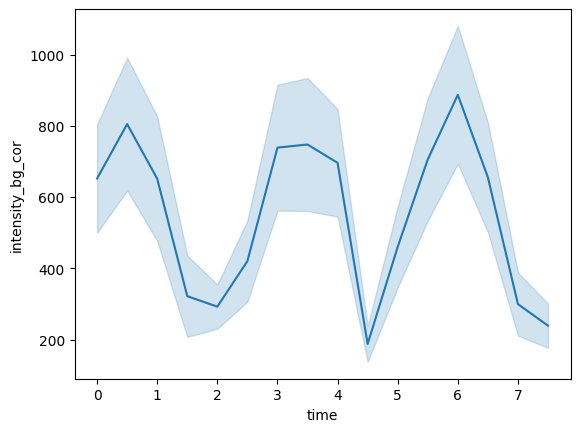

In [41]:
sns.lineplot(data=df, x="time", y="intensity_bg_cor", errorbar="sd")

<Axes: xlabel='time', ylabel='intensity_bg_cor'>

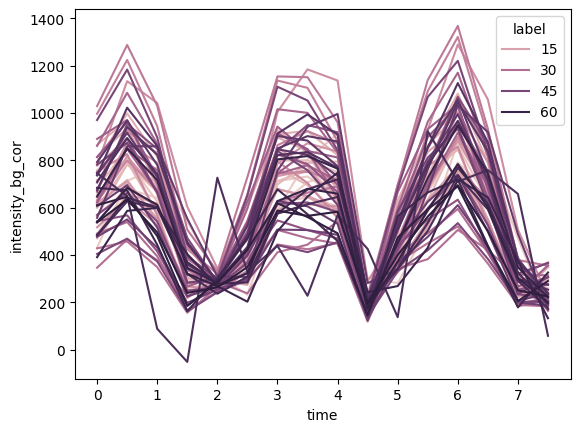

In [42]:
sns.lineplot(data=df, x="time", y="intensity_bg_cor", hue="label")